In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/HUMAN DATASET/Human_Data_Sequence.csv')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# first 10 rows
print("Dataset Loaded ")
display(df.head(10))

Dataset Loaded 


,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3
5,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
6,ATGAAGATTGCACACAGAGGTCCAGATGCATTCCGTTTTGAGAATG...,3
7,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3
8,ATGAAGATTGCACACAGAGGTCCAGATGCATTCCGTTTTGAGAATG...,3
9,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3


In [7]:
#structure check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sequence  4380 non-null   object
 1   class     4380 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 68.6+ KB


In [8]:
df.isnull().sum()

,0
sequence,0
class,0


In [9]:
#fill missing value
df['sequence'] = df['sequence'].fillna('unknown')

In [10]:
df.isnull().sum()

,0
sequence,0
class,0


In [11]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sequence  4380 non-null   object
 1   class     4380 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 68.6+ KB
None


In [12]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sequence    0
class       0
dtype: int64


In [20]:
df['class'].value_counts()

,count
class,
6,1343
4,711
3,672
1,534
0,531
2,349
5,240


In [21]:
print(df.columns)

Index(['sequence', 'class', 'clean_text'], dtype='object')


In [13]:

# TEXT CLEANING IN ONE CELL
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                           # lowercase
    text = re.sub(r'http\S+', '', text)           # remove links
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'[^a-zA-Z]', ' ', text)        # keep alphabets only
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# APPLYING TO DATAFRAME COLUMN
df['clean_text'] = df['sequence'].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,sequence,class,clean_text
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,atgccccaactaaatactaccgtatggcccaccataattaccccca...
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,atgaacgaaaatctgttcgcttcattcattgcccccacaatcctag...
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,atgtgtggcatttgggcgctgtttggcagtgatgattgcctttctg...
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,atgtgtggcatttgggcgctgtttggcagtgatgattgcctttctg...
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,atgcaacagcattttgaatttgaataccagaccaaagtggatggtg...


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#improve tokenization
max_words = 10000
max_len = 150
tokenizer = Tokenizer(num_words=max_words,oov_token="<oov>")
tokenizer.fit_on_texts(df['clean_text'])
x=tokenizer.texts_to_sequences(df['clean_text'])
x=pad_sequences(x,maxlen=max_len)

In [17]:
#improve tokenization
max_words = 10000
max_len = 150
tokenizer = Tokenizer(num_words=max_words, oov_token="<oov>")
tokenizer.fit_on_texts(df['clean_text'])
x = tokenizer.texts_to_sequences(df['clean_text'])
x = pad_sequences(x, maxlen=max_len)

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['class'])

In [19]:
# Import necessary libraries for text cleaning
import re
import nltk
from nltk.corpus import stopwords

# Define the text cleaning function and stop_words set
# The NLTK stopwords dataset needs to be downloaded once, usually done in a previous cell.
# If you encounter a LookupError, run: nltk.download('stopwords') in a separate cell.
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                           # lowercase
    text = re.sub(r'http\S+', '', text)           # remove links
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'[^a-zA-Z]', ' ', text)        # keep alphabets only
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Check if 'clean_text' column exists, if not, create it
if 'clean_text' not in df.columns:
    df['clean_text'] = df['sequence'].apply(clean_text)

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['class']

# Encode Labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log)*100)


===== Logistic Regression =====
Accuracy: 44.97716894977169


In [26]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("===== SVM =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm)*100)


===== SVM =====
Accuracy: 47.37442922374429


In [27]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("===== Naive Bayes =====")
print("Accuracy:", accuracy_score(y_test, y_pred_nb)*100)


===== Naive Bayes =====
Accuracy: 40.75342465753425


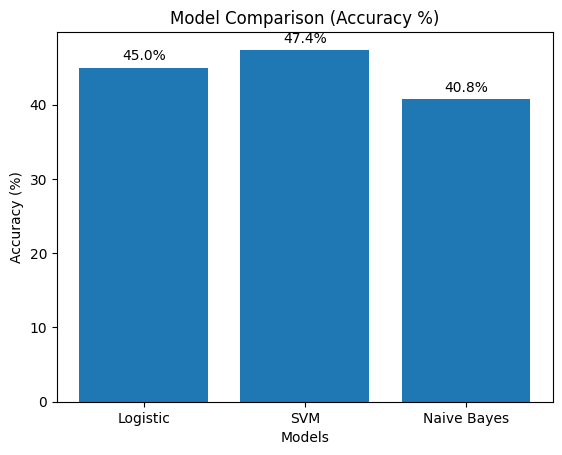

In [28]:
models = ['Logistic', 'SVM', 'Naive Bayes']

scores = [
    accuracy_score(y_test, y_pred_log)*100,
    accuracy_score(y_test, y_pred_svm)*100,
    accuracy_score(y_test, y_pred_nb)*100
]
plt.bar(models, scores)

plt.title("Model Comparison (Accuracy %)")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(scores):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')

plt.show()

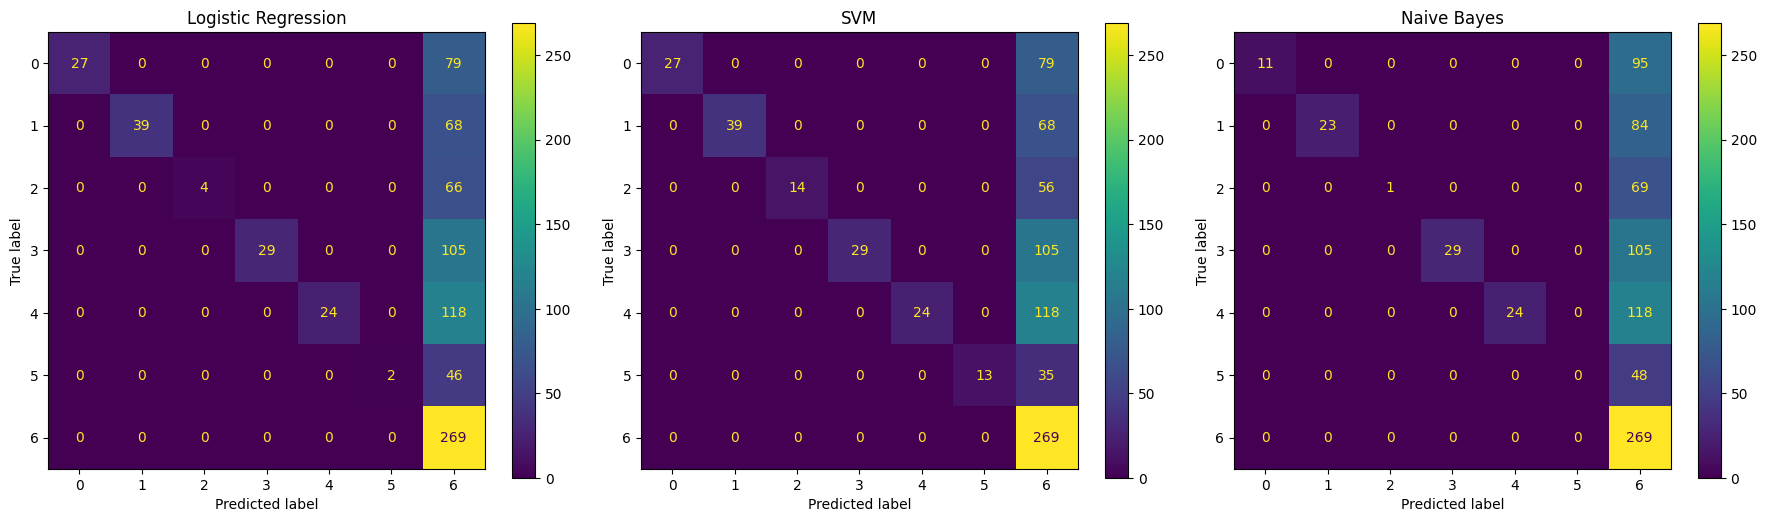

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm).plot(ax=axes[1])
axes[1].set_title("SVM")

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb).plot(ax=axes[2])
axes[2].set_title("Naive Bayes")

# Adjust layout
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report

# Logistic Regression Report
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log))

# SVM Report
print("===== SVM =====")
print(classification_report(y_test, y_pred_svm))

# Naive Bayes Report
print("===== Naive Bayes =====")
print(classification_report(y_test, y_pred_nb))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.25      0.41       106
           1       1.00      0.36      0.53       107
           2       1.00      0.06      0.11        70
           3       1.00      0.22      0.36       134
           4       1.00      0.17      0.29       142
           5       1.00      0.04      0.08        48
           6       0.36      1.00      0.53       269

    accuracy                           0.45       876
   macro avg       0.91      0.30      0.33       876
weighted avg       0.80      0.45      0.39       876

===== SVM =====
              precision    recall  f1-score   support

           0       1.00      0.25      0.41       106
           1       1.00      0.36      0.53       107
           2       1.00      0.20      0.33        70
           3       1.00      0.22      0.36       134
           4       1.00      0.17      0.29       142
           5       1.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
